# Question 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from function import iteration_function

x_range = np.linspace(-2, 2, 500)
y_range = np.linspace(-2, 2, 500)
max_iterations = 500

iteration_results = np.zeros((len(y_range), len(x_range)))

for i, y in enumerate(y_range):
    for j, x in enumerate(x_range):
        c = complex(x, y)
        iteration_results[i, j] = iteration_function(c,max_iterations)

In [ ]:
is_bounded = (iteration_results == max_iterations)

plt.figure(figsize=(10, 10))
plt.imshow(is_bounded, extent=[-2, 2, -2, 2], cmap='binary')
plt.title("Bounded (Black) vs. Diverged (White)")
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("bounded_vs_divergent.pdf")
plt.show()

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(iteration_results, extent=[-2, 2, -2, 2], cmap='magma')
plt.colorbar(label="Number of Iterations")
plt.title("Divergence Iteration with Colour Scale")
plt.xlabel("x")
plt.ylabel("y")
plt.savefig("colour_scaled_iterations.pdf") 
plt.show()

# Question 2

Step 1. code up the equations, using a function definition, with a proper docstrings (inside triple quotes)

In [ ]:
from scipy.integrate import solve_ivp

In [ ]:
def lorenz_equations(t, W, sigma, r, b):
    """
    Computes the Lorenz equations to be integrated.

    Parameters:
    -----------
    t : float
        The current time (dimensionless).
    W : list or array
        A list or array containing the variables [x, y, z].
    sigma : float
        The Prandtl number. the ratio of the kinematic viscosity to the thermal diffusivity
    r : float
        The Rayleigh number. (which depends on the vertical temperature difference between the top and bottom of the atmosphere)
    b : float
        A dimensionless length scale. 

    Returns:
    --------
    list
        The rates of change [dX/dt, dY/dt, dZ/dt] at the current time t.
    """
    x, y, z = W
    
    X_dot = -sigma * (x-y)
    Y_dot = (r*x) -y - (x*z)
    Z_dot = -(b*z) + (x*y)
    
    return [X_dot,Y_dot,Z_dot]

Step 2. use an ode solver of your choice, i.e., solve ivp, or ode, to integrate the equations for t=60 (in dimensionless time units). Use Lorenz’ initial conditions W0 = [0., 1., 0.] and his parameter values [σ, r, b] =
[10., 28, 8./3.].

In [ ]:
sigma = 10.0
r = 28.0
b = 8/3.0
W0 = [0.0, 1.0, 0.0]
t_span = (0, 60)
sol = solve_ivp(lorenz_equations, t_span, W0, args=(sigma, r, b), dense_output=True)

Step 3. Reproduce Lorenz’ Figure 1. Label both axes! Note that Lorenz uses N = t/∆t to label his plots (here
∆t = 0.01).

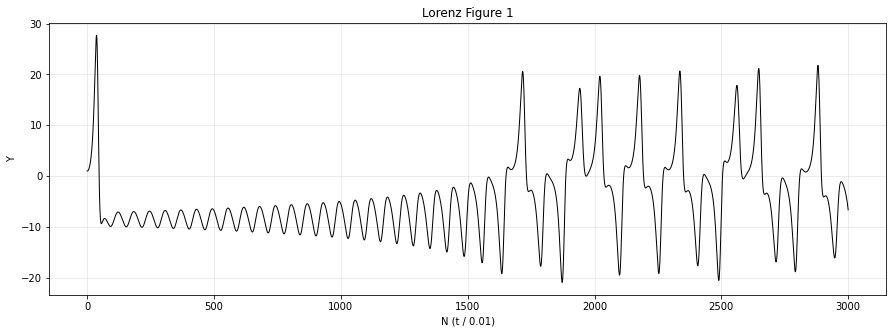

In [10]:
dt = 0.01
time_vals = np.linspace(0, 30, 3000)
Y_vals = sol.sol(time_vals)[1] 
N_axis = time_vals / dt
plt.figure(figsize=(15, 5))
plt.plot(N_axis, Y_vals, color='black', linewidth=1)
plt.title("Lorenz Figure 1")
plt.xlabel("N (t / 0.01)")
plt.ylabel("Y")
plt.grid(True, alpha=0.3)
plt.savefig("lorenz_fig1.pdf")
plt.show()

Step 4. Reproduce Lorenz’ Figure 2. You will likely have to ask for output at very closely spaced time intervals,
e.g., if you use solve ivp, you will need something like t = np.linspace(14, 19, 1000) followed by W =
sol.sol(t). Again, label both axes.

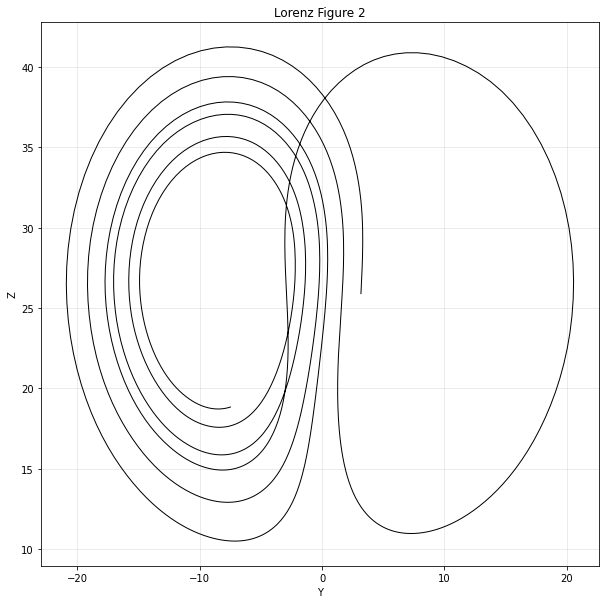

In [11]:
t = np.linspace(14, 19, 1000)
W = sol.sol(t)
Y = W[1]
Z = W[2]
plt.figure(figsize=(10, 10))
plt.plot(Y, Z, color='black', linewidth=1)
plt.title("Lorenz Figure 2")
plt.xlabel("Y")
plt.ylabel("Z")
plt.grid(True, alpha=0.3)
plt.savefig("lorenz_fig2.pdf")
plt.show()

Step 5. Now find the solution using the same values of (σ, r, b), but this time with initial conditions very slightly different than W0, say W0. 0 = W0 + [0., 1.e − 8, 0] = [0., 1.00000001, 0.]; note that adding the two lists (as indicated here) will not work, so you should google to find out how to add two lists element by element. Calculate the distance between W0 and W as a function of time, and plot the result on a semilog plot (linear time, log distance). A straight line on such a plot, which is what Lorenz found, indicates exponential growth. Thus a small error in the initial condition will grow rapidly, meaning that predictions of future behavior will not be accurate.

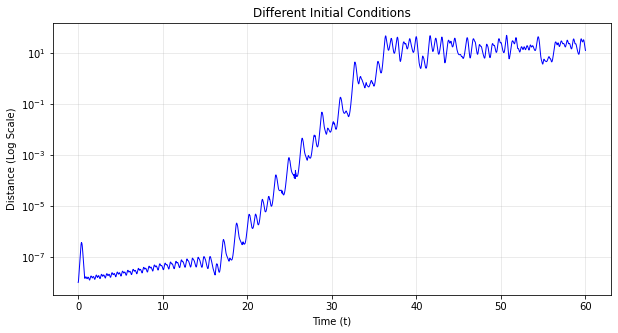

In [14]:
W0 = np.array([0.0, 1.0, 0.0])
W0_new = W0 + np.array([0.0, 1e-8, 0.0])
sol_new = solve_ivp(lorenz_equations, (0, 60), W0_new, args=(sigma, r, b), dense_output=True)

time_difference = np.linspace(0, 60, 5000)
W_first = sol.sol(time_difference)
W_changed = sol_new.sol(time_difference)
difference = W_first - W_changed
distance = np.sqrt(np.sum(difference**2, axis=0))
plt.figure(figsize=(10, 5))
plt.semilogy(time_difference, distance, color='blue', linewidth=1)
plt.title("Different Initial Conditions")
plt.xlabel("Time (t)")
plt.ylabel("Distance (Log Scale)")
plt.grid(True, which="both", alpha=0.3)
plt.savefig("lorenz_sensitivity.pdf")
plt.show()